# Análisis Univariado de Variables Numéricas
**Objetivo:** Explorar la distribución, estadísticos descriptivos y detección de valores atípicos (outliers) de todas las variables numéricas continuas y discretas del dataset `train_processed.csv`.

**Pasos:**
1. Carga y reconocimiento de datos.
2. Filtrado inteligente de variables numéricas (excluyendo IDs, ZIP codes y coordenadas).
3. Análisis de estadísticos descriptivos y valores faltantes.
4. Visualización de distribuciones (Histogramas con KDE).
5. Detección de Outliers (Boxplots).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

# Configuración de estilo y advertencias
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

# Configuración para mostrar todas las columnas en los dataframes
pd.set_option('display.max_columns', None)

In [2]:
# 1. Carga del dataset
df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv", low_memory=False)

#df = pd.read_csv('train_processed.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# 2. Selección de variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 3. Filtrado de columnas que no aportan al análisis de distribución (IDs, ZIP, Lat, Long)
# Buscamos patrones en los nombres de las columnas (insensible a mayúsculas/minúsculas)
exclude_patterns = [r'id', r'zip', r'code', r'lat', r'long', r'coord']
cols_to_exclude = [col for col in numeric_cols if any(re.search(p, col.lower()) for p in exclude_patterns)]

# Filtramos las columnas a analizar
cols_to_analyze = [col for col in numeric_cols if col not in cols_to_exclude]

print(f"Total de variables numéricas originales: {len(numeric_cols)}")
print(f"Variables excluidas (IDs, ZIP, Coordenadas): {cols_to_exclude}")
print(f"Variables numéricas a analizar: {len(cols_to_analyze)}\n")
print("Columnas a analizar:", cols_to_analyze)

Dimensiones del dataset: 11840 filas y 46 columnas.

Total de variables numéricas originales: 44
Variables excluidas (IDs, ZIP, Coordenadas): ['zpid', 'latitude', 'longitude', 'zipcode', 'latest_tax_value', 'latest_tax_paid', 'zip_3digit', 'desc_is_boilerplate']
Variables numéricas a analizar: 36

Columnas a analizar: ['lastSoldPrice_hpi_adjusted', 'log_price', 'bedrooms', 'bathrooms', 'livingArea', 'yearBuilt', 'lotAreaValue', 'photoCount', 'taxAssessedValue', 'propertyTaxRate', 'num_tax_records', 'num_sales', 'num_price_changes', 'last_listing_price', 'avg_school_rating', 'max_school_rating', 'num_nearby_schools', 'min_school_distance', 'has_hoa', 'hoa_fee_monthly', 'has_pool', 'has_garage', 'has_waterfront', 'tag_price_cut', 'tag_new_construction', 'tag_foreclosure', 'property_age', 'bath_to_bed_ratio', 'log_living_area', 'log_lot_area', 'desc_length', 'desc_word_count', 'desc_mentions_renovated', 'desc_mentions_pool', 'desc_mentions_view', 'desc_mentions_new']


In [3]:
# Estadísticos descriptivos
display(df[cols_to_analyze].describe().T)

# Análisis de valores faltantes en variables numéricas
missing_numeric = df[cols_to_analyze].isnull().sum()
missing_numeric_pct = (missing_numeric / len(df)) * 100

missing_df = pd.DataFrame({
    'Valores_Faltantes': missing_numeric,
    'Porcentaje (%)': missing_numeric_pct
}).sort_values(by='Porcentaje (%)', ascending=False)

# Mostramos solo las que tienen al menos un valor faltante
print("\n--- Valores Faltantes en Variables Numéricas ---")
display(missing_df[missing_df['Valores_Faltantes'] > 0])

,count,mean,std,min,25%,50%,75%,max
lastSoldPrice_hpi_adjusted,11840.0,559019.362237,350971.426392,51275.851673,303966.301588,472289.030264,729278.033249,1.986843e+06
log_price,11840.0,13.032547,0.663308,10.844995,12.624675,13.065349,13.499812,1.450206e+01
bedrooms,11360.0,2.446743,1.047838,0.000000,2.000000,2.000000,3.000000,1.100000e+01
bathrooms,11615.0,1.973250,0.752093,0.000000,1.500000,2.000000,2.000000,1.000000e+01
livingArea,11668.0,1417.349417,669.386605,0.000000,970.000000,1311.000000,1728.250000,2.516300e+04
yearBuilt,11529.0,1975.436204,21.475135,1900.000000,1960.000000,1973.000000,1989.000000,2.027000e+03
lotAreaValue,6494.0,4679.379708,3457.822771,0.000000,997.000000,5501.000000,7500.750000,1.873080e+04
photoCount,11840.0,11.403294,17.619715,1.000000,1.000000,1.000000,18.000000,3.510000e+02
taxAssessedValue,11316.0,304907.683369,210222.886740,300.000000,151734.000000,253835.500000,399658.750000,1.744567e+06
propertyTaxRate,11838.0,1.795575,0.235849,0.000000,1.740000,1.840000,1.840000,2.130000e+00



--- Valores Faltantes en Variables Numéricas ---


,Valores_Faltantes,Porcentaje (%)
log_lot_area,5346,45.152027
lotAreaValue,5346,45.152027
last_listing_price,3925,33.150338
bath_to_bed_ratio,582,4.915541
taxAssessedValue,524,4.425676
bedrooms,480,4.054054
yearBuilt,311,2.626689
property_age,311,2.626689
bathrooms,225,1.900338
livingArea,172,1.452703


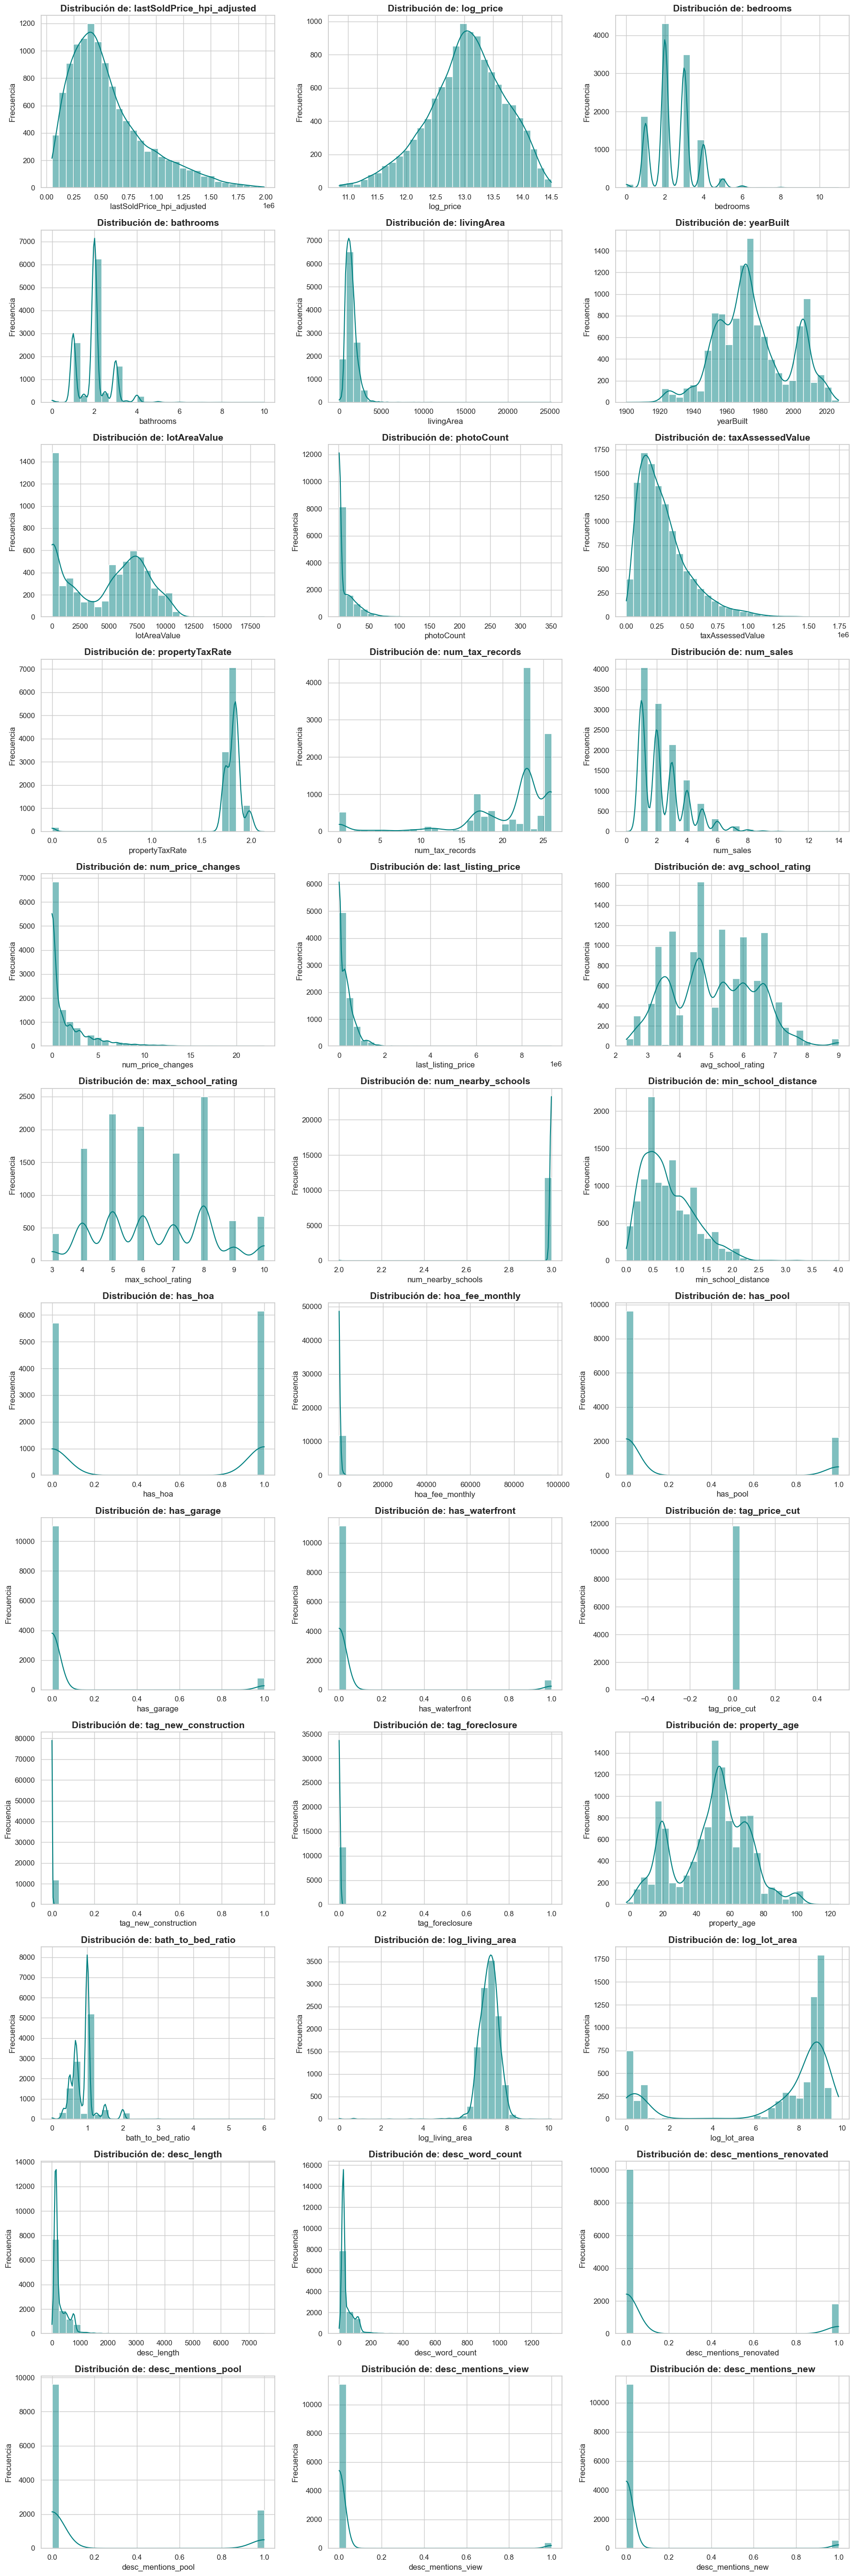

In [4]:
def plot_distributions(data, columns, bins=30):
    """Genera un grid de histogramas con curvas KDE para las columnas indicadas."""
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.histplot(data[col].dropna(), kde=True, ax=axes[i], bins=bins, color='teal', edgecolor='white')
        axes[i].set_title(f'Distribución de: {col}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Frecuencia', fontsize=12)
        
    # Ocultar ejes vacíos si el número de columnas no es múltiplo de 3
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Ejecutar gráfico de distribuciones
if len(cols_to_analyze) > 0:
    plot_distributions(df, cols_to_analyze)
else:
    print("No hay variables numéricas continuas para graficar tras el filtrado.")

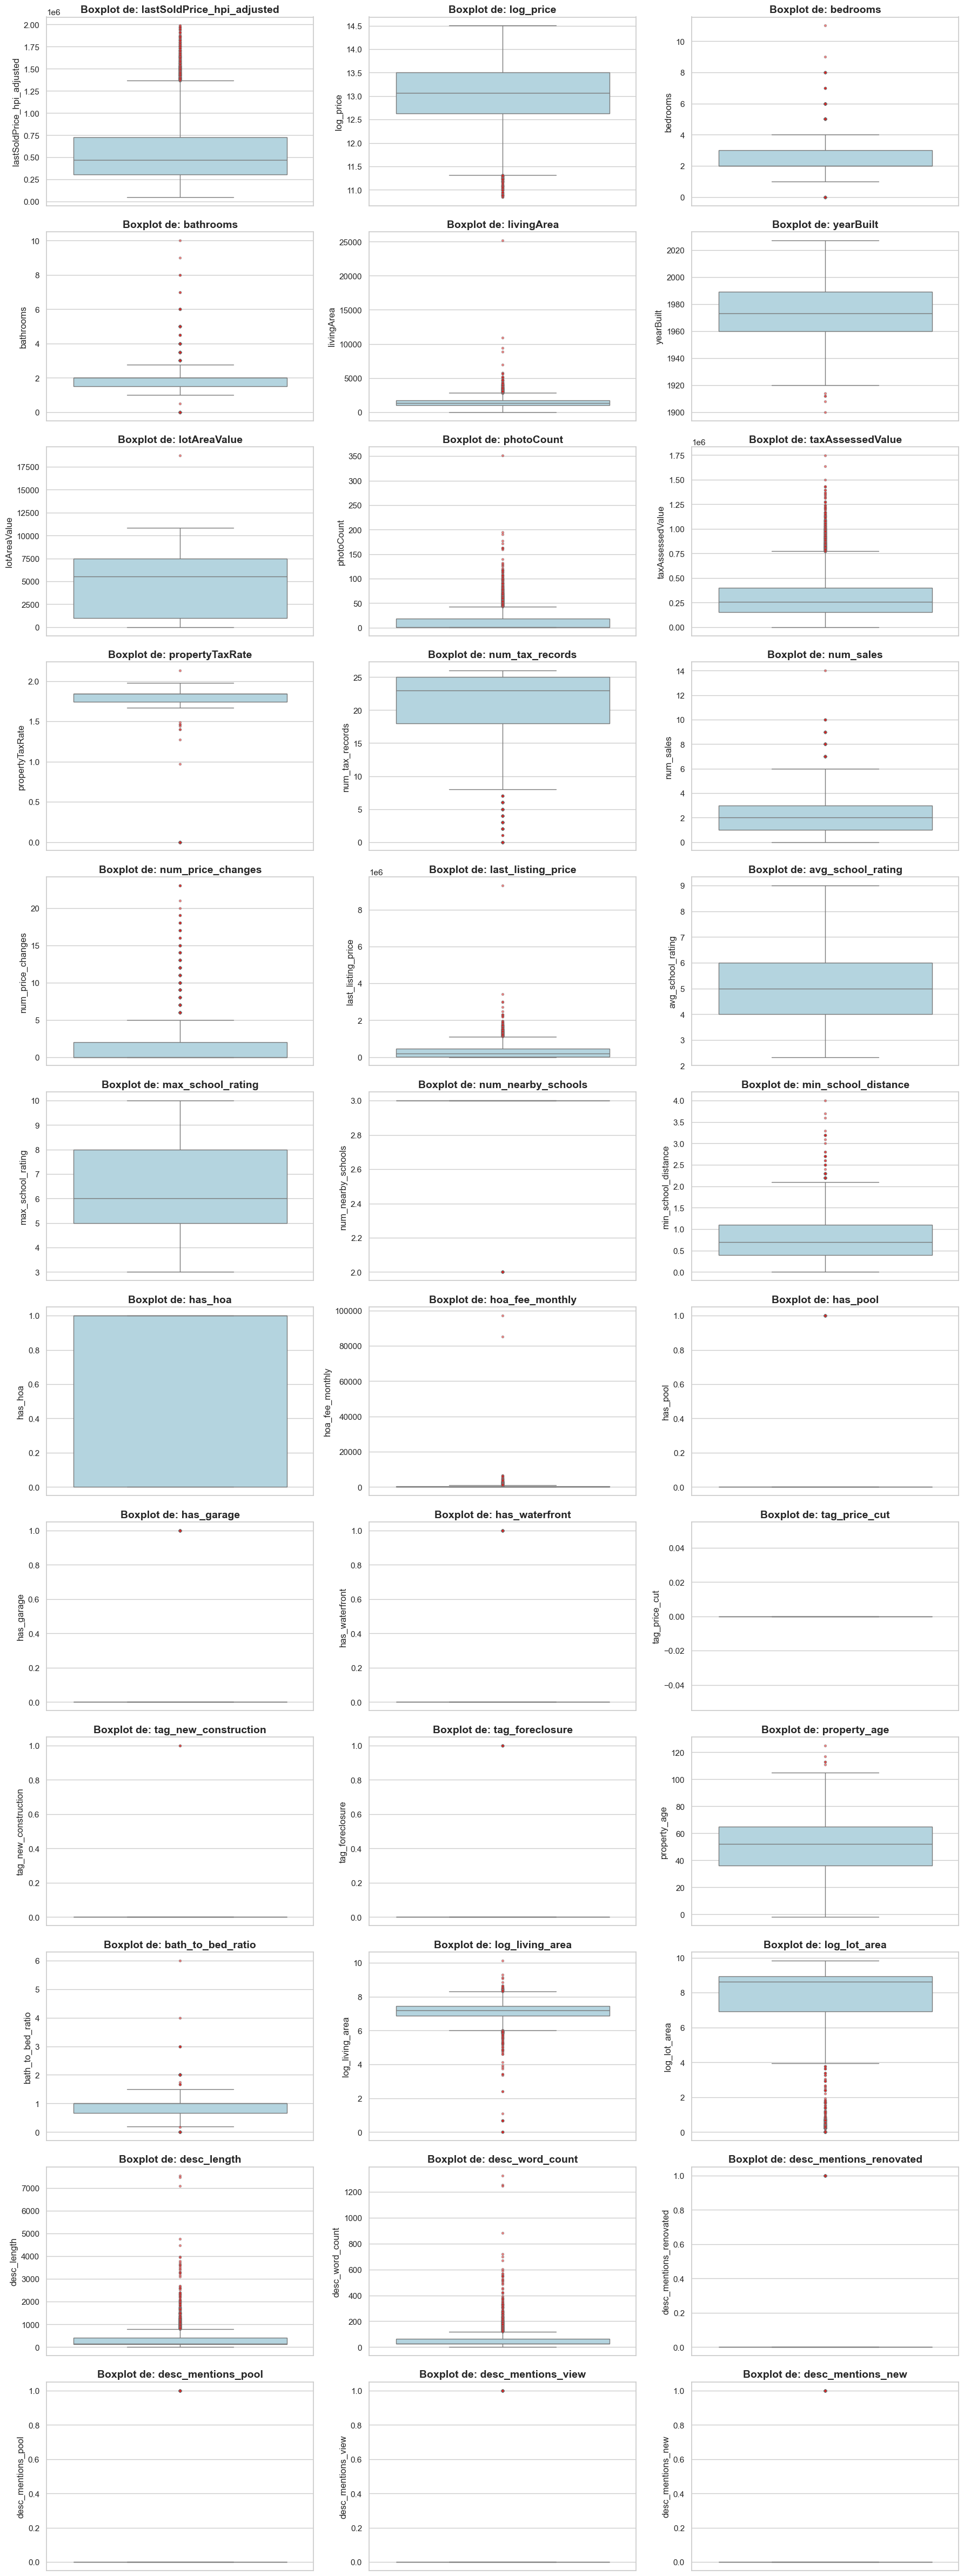

In [5]:
def plot_boxplots(data, columns):
    """Genera un grid de boxplots para identificar valores atípicos."""
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.boxplot(y=data[col], ax=axes[i], color='lightblue', fliersize=3, flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
        axes[i].set_title(f'Boxplot de: {col}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=12)
        axes[i].set_xticks([]) # Ocultar eje x ya que es una sola variable
        
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Ejecutar gráfico de boxplots
if len(cols_to_analyze) > 0:
    plot_boxplots(df, cols_to_analyze)

## 📊 Conclusiones del Análisis Univariado

1. **Distribuciones y Sesgo (Skewness):** 
   - *Observar aquí si variables como el Precio o Tamaño (sqft) presentan una cola larga a la derecha (sesgo positivo).*
   - **Acción sugerida:** Si se van a utilizar modelos de Machine Learning sensibles a la escala (como Regresión Lineal, Redes Neuronales o K-Means), se recomienda aplicar transformaciones (ej. `log1p`) a las variables con alto sesgo.

2. **Valores Atípicos (Outliers):**
   - *Identificar aquí qué variables presentan puntos rojos en los boxplots.*
   - **Acción sugerida:** Evaluar si los outliers son errores de carga de datos (a eliminar/imputar) o casos de negocio reales y válidos (ej. mansiones de lujo en el dataset de bienes raíces) que el modelo debe aprender a predecir.

3. **Varianza Nula o Constante:**
   - Revisar en la tabla de estadísticos descriptivos si alguna variable tiene `std = 0`. Estas columnas no aportan información y deben ser eliminadas antes del modelado.